# Desafio

## Monitoramento de Desmatamento com Índices Espectrais

Você é um analista de sensoriamento remoto no INPE (Instituto Nacional de Pesquisas Espaciais) e recebeu dados simulados de duas imagens de satélite da mesma região da Amazônia, com 6 meses de diferença.

**Tarefa:**

1. Crie dois arrays 200x200 representando o NDVI da região em duas datas diferentes (`ndvi_jan2024` e `ndvi_jul2024`). Use `np.random.seed(123)` para reprodutibilidade.
   - Janeiro deve ter valores mais altos de NDVI (estação chuvosa, vegetação exuberante)
   - Julho deve ter valores mais baixos (estação seca, possível desmatamento)

2. Calcule a diferença entre as duas imagens: `diferenca = ndvi_jan2024 - ndvi_jul2024`

3. Identifique as áreas de possível desmatamento onde a diferença de NDVI é maior que 0.3 (indicando perda significativa de vegetação)

4. Calcule:
   - A área total desmatada (número de pixels e percentual)
   - O NDVI médio na área desmatada em cada data
   - O valor máximo de NDVI perdido

5. Crie uma "máscara de alerta" — um array booleano marcando as áreas críticas

**Dica:** Use `np.random.uniform()` ou `np.random.normal()` para gerar os dados de NDVI com distribuições diferentes para cada data.

In [28]:
import pandas as pd
import numpy as np

In [29]:
np.random.seed(123)

#simulando o NDVI alto em janeiro (valores entre 0.5 e 0.9)
#ndvi_jan = np.random.random((200, 200)) * 0.4 + 0.5
ndvi_jan = np.random.uniform(0.5, 0.9, (200, 200))

#simulando o NDVI baixo para julho (valores entre 0.1 a 0.5)
#ndvi_julho = np.random.random((200, 200)) * 0.4 + 0.1
ndvi_julho = np.random.uniform(0.1, 0.5, (200,200))

print(f"Media NDVI Janeiro: {ndvi_jan.mean():.4f}")
print(f"Media NDVI Julho: {ndvi_julho.mean():.4f}")

Media NDVI Janeiro: 0.7003
Media NDVI Julho: 0.3002


Verificando quanto o NDVI caiu de Janeiro para Julho em cada ponto do terreno.

In [30]:
diferenca = ndvi_jan - ndvi_julho

print(f"Diferença média de NDVI: {diferenca.mean():.4f}")
print(f"A maior perda de NDVI encontrada foi: {diferenca.max():.4f}")

Diferença média de NDVI: 0.4002
A maior perda de NDVI encontrada foi: 0.7981


Quais regiões agrícolas sofreram mais? Para responder essa pergunta é necessário primeiro filtrar as áreas críticas e depois gerar um mapa visual

In [31]:
#mascara de alerta, exibindo as áreas mais afetadas
estresse_severo = diferenca > 0.3

#calculando o tamanho da área afetada
quant_pixels_afetados = np.sum(estresse_severo)
porcentagem = (quant_pixels_afetados / (200 * 200)) * 100

print(f"Quantidade de áreas em estresse hídrico severo: {quant_pixels_afetados}")
print(f"Porcentagem da área afetada: {porcentagem}%")
print(f"A área mais atingida teve alteração de: {diferenca.max():.4f} no NDVI")

Quantidade de áreas em estresse hídrico severo: 28717
Porcentagem da área afetada: 71.7925%
A área mais atingida teve alteração de: 0.7981 no NDVI


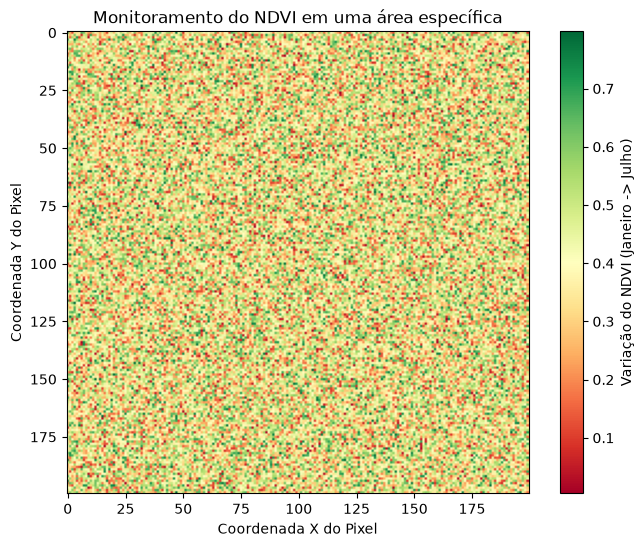

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

#exibindo a diferença entre os meses de janeiro e julho
plt.imshow(diferenca, cmap="RdYlGn")
plt.colorbar(label="Variação do NDVI (Janeiro -> Julho)")

plt.title("Monitoramento do NDVI em uma área específica")
plt.xlabel("Coordenada X do Pixel")
plt.ylabel("Coordenada Y do Pixel")

plt.show()